In [ ]:
# In the name of GOD, the Most Gracious, the Most Merciful

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import math

In [3]:
import copy

In [4]:
def calculate_f1(precision, recall):

    if (
        precision is None
        or
        recall is None
    ):
        return None

    denominator = precision + recall

    if denominator == 0:
        return None

    return (
        2 * precision * recall
    ) / denominator

In [5]:
def calculate_gmean(recall, specificity):

    if (
        recall is None
        or
        specificity is None
    ):
        return None

    return math.sqrt(
        recall * specificity
    )

In [6]:
# Here, "alert_list_without_Normal" contains Normal alerts as well because as explained in the experiments Normal alerts are not removed from "alert_list_without_Normal" and the same name is used for it for consistency 
# Initialise empty lists to store data
all_Number_total_alerts = []
all_alert_list_without_Normal = []
all_alert_list_without_Normal_with_revised_priority = []
all_alert_list_without_Normal_without_revised_priority = []
all_alert_after_action_01 = []
all_Final_alert_list_without_Normal_addressed = []
all_Final_alert_list_without_Normal_NotAddressed = []
all_Analyst_workload = []
all_Remaining_time = []
all_len_Critical_storage = []
all_len_High_storage = []
all_len_Moderate_storage = []
all_len_Low_storage = []
all_len_Normal_storage = []
all_time_step_execution_time = []



for i in range(1,2017): 
    
    file_path = rf'C:\\...\\L2D_CICIDS2017_time_step_{i}.json'
                
    # read the JSON file
    with open(file_path, 'r') as json_file:
        data = json.load(json_file)
  
    number_total_alerts = data["Number_total_alerts"]
    all_Number_total_alerts.append(number_total_alerts)
    
    alert_list_without_Normal = data["alert_list_without_Normal"]
    all_alert_list_without_Normal.append(alert_list_without_Normal)
    
    alert_list_without_Normal_with_revised_priority = data["alert_list_without_Normal_with_revised_priority"]
    all_alert_list_without_Normal_with_revised_priority.append(alert_list_without_Normal_with_revised_priority)

    alert_list_without_Normal_without_revised_priority = data["alert_list_without_Normal_without_revised_priority"]
    all_alert_list_without_Normal_without_revised_priority.append(alert_list_without_Normal_without_revised_priority)
    
    alert_after_action_01 = data["alerts_after_action_01"]
    all_alert_after_action_01.append(alert_after_action_01)
    
    Final_alert_list_without_Normal_addressed = data["Final_alert_list_without_Normal_addressed"]
    all_Final_alert_list_without_Normal_addressed.append(Final_alert_list_without_Normal_addressed)
    
    Final_alert_list_without_Normal_NotAddressed = data["Final_alert_list_without_Normal_NotAddressed"]
    all_Final_alert_list_without_Normal_NotAddressed.append(Final_alert_list_without_Normal_NotAddressed)

    time_step_execution_time = data["time_step_execution_time"]
    all_time_step_execution_time.append(time_step_execution_time)
    
    
    Analyst_workload = data["Analyst_Workload"]
    all_Analyst_workload.append(Analyst_workload)
    
    Remaining_time = data["Remaining_time"]
    all_Remaining_time.append(Remaining_time)
    

In [ ]:
# Number of received, prioritised, un-prioritised 

In [7]:
len(all_alert_list_without_Normal[1])

422

In [8]:
len(all_Final_alert_list_without_Normal_addressed[1])

356

In [9]:
len(all_Final_alert_list_without_Normal_NotAddressed[1])

66

In [10]:
# Initialize counts
priority_counts_without_Normal = {0.0: 0, 1.0: 0, 2.0: 0, 3.0: 0, 4.0: 0}

# Loop through all inner lists and alerts
for inner_list in all_alert_list_without_Normal:
    for alert in inner_list:
        priority = alert.get('priority_Analyst')
        if priority in priority_counts_without_Normal:
            priority_counts_without_Normal[priority] += 1

# Calculate average for each priority
total_alerts = sum(priority_counts_without_Normal.values())
average_per_priority = {priority: count / len(all_alert_list_without_Normal) for priority, count in priority_counts_without_Normal.items()}

# Display results
print("Priority counts_all_alert_list_without_Normal:", priority_counts_without_Normal)
print("Average alerts per priority_all_alert_list_without_Normal:", average_per_priority)

Priority counts_all_alert_list_without_Normal: {0.0: 646045, 1.0: 0, 2.0: 121209, 3.0: 36533, 4.0: 553}
Average alerts per priority_all_alert_list_without_Normal: {0.0: 320.45882936507934, 1.0: 0.0, 2.0: 60.123511904761905, 3.0: 18.12152777777778, 4.0: 0.2743055555555556}


In [11]:
# Initialize counts 
priority_counts_without_Normal_addressed = {0.0: 0, 1.0: 0, 2.0: 0, 3.0: 0, 4.0: 0}

# Loop through all inner lists and alerts
for inner_list in all_Final_alert_list_without_Normal_addressed:
    for alert in inner_list:
        priority = alert.get('priority_Analyst')
        if priority in priority_counts_without_Normal_addressed:
            priority_counts_without_Normal_addressed[priority] += 1

# Calculate average for each priority
total_alerts = sum(priority_counts_without_Normal_addressed.values())
average_per_priority = {priority: count / len(all_Final_alert_list_without_Normal_addressed) for priority, count in priority_counts_without_Normal_addressed.items()}

# Display results
print("Priority counts_all_Final_alert_list_without_Normal_addressed:", priority_counts_without_Normal_addressed)
print("Average alerts per priority_all_Final_alert_list_without_Normal_addressed:", average_per_priority)

Priority counts_all_Final_alert_list_without_Normal_addressed: {0.0: 570449, 1.0: 0, 2.0: 100203, 3.0: 28202, 4.0: 450}
Average alerts per priority_all_Final_alert_list_without_Normal_addressed: {0.0: 282.9608134920635, 1.0: 0.0, 2.0: 49.70386904761905, 3.0: 13.989087301587302, 4.0: 0.22321428571428573}


In [12]:
# Initialize counts
priority_counts_without_Normal_NotAddressed = {0.0: 0, 1.0: 0, 2.0: 0, 3.0: 0, 4.0: 0}

# Loop through all inner lists and alerts
for inner_list in all_Final_alert_list_without_Normal_NotAddressed:
    for alert in inner_list:
        priority = alert.get('priority_Analyst')
        if priority in priority_counts_without_Normal_NotAddressed:
            priority_counts_without_Normal_NotAddressed[priority] += 1

# Calculate average for each priority
total_alerts = sum(priority_counts_without_Normal_NotAddressed.values())
average_per_priority = {priority: count / len(all_Final_alert_list_without_Normal_NotAddressed) for priority, count in priority_counts_without_Normal_NotAddressed.items()}

# Display results
print("Priority counts_all_Final_alert_list_without_Normal_NotAddressed:", priority_counts_without_Normal_NotAddressed)
print("Average alerts per priority_all_Final_alert_list_without_Normal_NotAddressed:", average_per_priority)

Priority counts_all_Final_alert_list_without_Normal_NotAddressed: {0.0: 75596, 1.0: 0, 2.0: 21006, 3.0: 8331, 4.0: 103}
Average alerts per priority_all_Final_alert_list_without_Normal_NotAddressed: {0.0: 37.49801587301587, 1.0: 0.0, 2.0: 10.419642857142858, 3.0: 4.132440476190476, 4.0: 0.05109126984126984}


In [13]:
# Function to compute the division of values with the same keys
def compute_division(dict1, dict2):
    result = {}
    for key in dict1:
        if dict1[key] != 0:
            result[key] = dict2[key] / dict1[key]
        else:
            result[key] = float('inf') # Handle division by zero
    return result

# Compute the divisions
addressed_division = compute_division(priority_counts_without_Normal, priority_counts_without_Normal_addressed)
not_addressed_division = compute_division(priority_counts_without_Normal, priority_counts_without_Normal_NotAddressed)

# Print the results
print("Division of addressed alerts:", addressed_division)
print("Division of not addressed alerts:", not_addressed_division)

Division of addressed alerts: {0.0: 0.8829864792700199, 1.0: inf, 2.0: 0.8266960374229636, 3.0: 0.7719595981715162, 4.0: 0.8137432188065099}
Division of not addressed alerts: {0.0: 0.11701352072998011, 1.0: inf, 2.0: 0.17330396257703637, 3.0: 0.22804040182848384, 4.0: 0.18625678119349007}


In [14]:
len(all_Number_total_alerts)

2016

In [15]:
# Calculating the number of normal alerts
whole_alert_number = sum(all_Number_total_alerts)
print("whole_alert_number =",whole_alert_number)

whole_alert_number = 804340


In [16]:
whole_alert_number_without_normal = sum(priority_counts_without_Normal.values())
print("whole_alert_number_without_normal =",whole_alert_number_without_normal)

whole_alert_number_without_normal = 804340


In [17]:
whole_alert_number_normal = whole_alert_number - whole_alert_number_without_normal
print("whole_alert_number_normal =",whole_alert_number_normal)
# it is 0 because all Normal alerts are included in "whole_alert_number_without_normal"

whole_alert_number_normal = 0


In [18]:
# Number of processed alerts
number_processed_alerts = sum(priority_counts_without_Normal_addressed.values())
print("number_processed_alerts= ", number_processed_alerts)

number_processed_alerts=  699304


In [19]:
# Number of processed alerts_excluded Normal
number_processed_alert_excluded_Normal = number_processed_alerts - priority_counts_without_Normal_addressed[0.0]
print("number_processed_alert_excluded_Normal= ", number_processed_alert_excluded_Normal)

number_processed_alert_excluded_Normal=  128855


In [20]:
# Number of un-processed alerts
number_un_processed_alerts = sum(priority_counts_without_Normal_NotAddressed.values())
print("number_un_processed_alerts= ", number_un_processed_alerts)

number_un_processed_alerts=  105036


In [21]:
percentage_processed_alerts = number_processed_alerts / whole_alert_number
print("percentage_processed_alerts =", percentage_processed_alerts)

percentage_processed_alerts = 0.869413432130691


In [22]:
percentage_un_processed_alerts = number_un_processed_alerts / whole_alert_number
print("percentage_un_processed_alerts =", percentage_un_processed_alerts)

percentage_un_processed_alerts = 0.130586567869309


In [23]:
len(all_Analyst_workload)

2016

In [24]:
len(all_alert_list_without_Normal)

2016

In [25]:
len(all_Final_alert_list_without_Normal_NotAddressed[1710])

16

In [26]:
len(all_alert_list_without_Normal[1760])

365

In [27]:
# for the addressed performance of L2D
new_all_Final_alert_list_without_Normal_addressed = copy.deepcopy(all_Final_alert_list_without_Normal_addressed)

In [28]:
A = []
for alerts_list in new_all_Final_alert_list_without_Normal_addressed:
    for alert in alerts_list:
        A.append(alert['revised_priority'])

In [29]:
print(set(A))
print(A[:20])

{0, 2, 3, 4}
[3, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 3, 0, 0, 2, 2, 0, 0, 0]


In [30]:
# Accuracy revised addressed (L2D)
accurate_overall_revised_addressed = 0
inaccurate_overall_revised_addressed = 0

accurate_critical_revised_addressed = 0
inaccurate_critical_revised_addressed = 0

accurate_high_revised_addressed = 0
inaccurate_high_revised_addressed = 0

accurate_medium_revised_addressed = 0
inaccurate_medium_revised_addressed = 0

accurate_low_revised_addressed = 0
inaccurate_low_revised_addressed = 0

accurate_normal_revised_addressed = 0
inaccurate_normal_revised_addressed = 0

accurate_without_normal_revised_addressed = 0
inaccurate_without_normal_revised_addressed = 0

for alert_list in new_all_Final_alert_list_without_Normal_addressed:
    for alert in alert_list:
        if alert['revised_priority']==alert['priority_Analyst']:
            accurate_overall_revised_addressed = accurate_overall_revised_addressed + 1
        else:
            inaccurate_overall_revised_addressed = inaccurate_overall_revised_addressed + 1
            
        if alert['priority_Analyst']==4:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_critical_revised_addressed = accurate_critical_revised_addressed + 1
            else:
                inaccurate_critical_revised_addressed = inaccurate_critical_revised_addressed + 1

        if alert['priority_Analyst']==3:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_high_revised_addressed = accurate_high_revised_addressed + 1
            else:
                inaccurate_high_revised_addressed = inaccurate_high_revised_addressed + 1

        if alert['priority_Analyst']==2:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_medium_revised_addressed = accurate_medium_revised_addressed + 1
            else:
                inaccurate_medium_revised_addressed = inaccurate_medium_revised_addressed + 1

        if alert['priority_Analyst']==1:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_low_revised_addressed = accurate_low_revised_addressed + 1
            else:
                inaccurate_low_revised_addressed = inaccurate_low_revised_addressed + 1

        if alert['priority_Analyst']==0:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_normal_revised_addressed = accurate_normal_revised_addressed + 1
            else:
                inaccurate_normal_revised_addressed = inaccurate_normal_revised_addressed + 1

        if alert['priority_Analyst']!=0:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_without_normal_revised_addressed = accurate_without_normal_revised_addressed + 1
            else:
                inaccurate_without_normal_revised_addressed = inaccurate_without_normal_revised_addressed + 1


accuracy_overall_revised_addressed = accurate_overall_revised_addressed / (accurate_overall_revised_addressed+inaccurate_overall_revised_addressed)
accuracy_critical_revised_addressed = accurate_critical_revised_addressed / (accurate_critical_revised_addressed+inaccurate_critical_revised_addressed)
accuracy_high_revised_addressed = accurate_high_revised_addressed / (accurate_high_revised_addressed+inaccurate_high_revised_addressed)
accuracy_medium_revised_addressed = accurate_medium_revised_addressed / (accurate_medium_revised_addressed+inaccurate_medium_revised_addressed)
#accuracy_low_revised_addressed = accurate_low_revised_addressed / (accurate_low_revised_addressed+inaccurate_low_revised_addressed)
accuracy_normal_revised_addressed = accurate_normal_revised_addressed / (accurate_normal_revised_addressed+inaccurate_normal_revised_addressed)
accuracy_without_normal_revised_addressed = accurate_without_normal_revised_addressed / (accurate_without_normal_revised_addressed+inaccurate_without_normal_revised_addressed)

print('accuracy_overall_revised_addressed =', accuracy_overall_revised_addressed)
print('accuracy_critical_revised_addressed =', accuracy_critical_revised_addressed)
print('accuracy_high_revised_addressed =', accuracy_high_revised_addressed)
print('accuracy_medium_revised_addressed =', accuracy_medium_revised_addressed)
#print('accuracy_low_revised_addressed =', accuracy_low_revised_addressed)
print('accuracy_normal_revised_addressed =', accuracy_normal_revised_addressed)
print('accuracy_without_normal_revised_addressed =', accuracy_without_normal_revised_addressed)

accuracy_overall_revised_addressed = 0.9619493095992587
accuracy_critical_revised_addressed = 0.6
accuracy_high_revised_addressed = 0.9366002411176513
accuracy_medium_revised_addressed = 0.7582607307166452
accuracy_normal_revised_addressed = 0.999267243872809
accuracy_without_normal_revised_addressed = 0.7967405222924994


In [31]:
# False prioritisation revised addressed (L2D)
false_Critical_revised_addressed = {'prediction_3_y_true_4_count':0, 
                            'prediction_2_y_true_4_count':0, 
                            'prediction_1_y_true_4_count':0, 
                            'prediction_0_y_true_4_count':0,
                            'prediction_4_y_true_4_count':0,
                            'prediction_Not4_y_true_4_count':0}
    
false_High_revised_addressed = {'prediction_4_y_true_3_count':0, 
                       'prediction_2_y_true_3_count':0, 
                       'prediction_1_y_true_3_count':0, 
                       'prediction_0_y_true_3_count':0,
                       'prediction_3_y_true_3_count':0,
                       'prediction_Not3_y_true_3_count':0}

false_Medium_revised_addressed = {'prediction_4_y_true_2_count':0, 
                         'prediction_3_y_true_2_count':0, 
                         'prediction_1_y_true_2_count':0, 
                         'prediction_0_y_true_2_count':0,
                         'prediction_2_y_true_2_count':0,
                         'prediction_Not2_y_true_2_count':0}

false_Low_revised_addressed = {'prediction_4_y_true_1_count':0, 
                      'prediction_3_y_true_1_count':0, 
                      'prediction_2_y_true_1_count':0, 
                      'prediction_0_y_true_1_count':0,
                      'prediction_1_y_true_1_count':0,
                      'prediction_Not1_y_true_1_count':0}

false_Normal_revised_addressed = {'prediction_4_y_true_0_count':0, 
                         'prediction_3_y_true_0_count':0, 
                         'prediction_2_y_true_0_count':0, 
                         'prediction_1_y_true_0_count':0,
                         'prediction_0_y_true_0_count':0,
                         'prediction_Not0_y_true_0_count':0}

for alert_list in new_all_Final_alert_list_without_Normal_addressed:
    for alert in alert_list:
        if alert['priority_Analyst']==4:
            if alert['revised_priority']==3:
                false_Critical_revised_addressed['prediction_3_y_true_4_count']+= 1
            if alert['revised_priority']==2:
                false_Critical_revised_addressed['prediction_2_y_true_4_count']+= 1
            if alert['revised_priority']==1:
                false_Critical_revised_addressed['prediction_1_y_true_4_count']+= 1
            if alert['revised_priority']==0:
                false_Critical_revised_addressed['prediction_0_y_true_4_count']+= 1
            if alert['revised_priority']==4:
                false_Critical_revised_addressed['prediction_4_y_true_4_count']+= 1
            if alert['revised_priority']!=4:
                false_Critical_revised_addressed['prediction_Not4_y_true_4_count']+= 1

        if alert['priority_Analyst']==3:
            if alert['revised_priority']==4:
                false_High_revised_addressed['prediction_4_y_true_3_count']+= 1
            if alert['revised_priority']==2:
                false_High_revised_addressed['prediction_2_y_true_3_count']+= 1
            if alert['revised_priority']==1:
                false_High_revised_addressed['prediction_1_y_true_3_count']+= 1
            if alert['revised_priority']==0:
                false_High_revised_addressed['prediction_0_y_true_3_count']+= 1
            if alert['revised_priority']==3:
                false_High_revised_addressed['prediction_3_y_true_3_count']+= 1
            if alert['revised_priority']!=3:
                false_High_revised_addressed['prediction_Not3_y_true_3_count']+= 1

        if alert['priority_Analyst']==2:
            if alert['revised_priority']==4:
                false_Medium_revised_addressed['prediction_4_y_true_2_count']+= 1
            if alert['revised_priority']==3:
                false_Medium_revised_addressed['prediction_3_y_true_2_count']+= 1
            if alert['revised_priority']==1:
                false_Medium_revised_addressed['prediction_1_y_true_2_count']+= 1
            if alert['revised_priority']==0:
                false_Medium_revised_addressed['prediction_0_y_true_2_count']+= 1
            if alert['revised_priority']==2:
                false_Medium_revised_addressed['prediction_2_y_true_2_count']+= 1
            if alert['revised_priority']!=2:
                false_Medium_revised_addressed['prediction_Not2_y_true_2_count']+= 1

        if alert['priority_Analyst']==1:
            if alert['revised_priority']==4:
                false_Low_revised_addressed['prediction_4_y_true_1_count']+= 1
            if alert['revised_priority']==3:
                false_Low_revised_addressed['prediction_3_y_true_1_count']+= 1
            if alert['revised_priority']==2:
                false_Low_revised_addressed['prediction_2_y_true_1_count']+= 1
            if alert['revised_priority']==0:
                false_Low_revised_addressed['prediction_0_y_true_1_count']+= 1
            if alert['revised_priority']==1:
                false_Low_revised_addressed['prediction_1_y_true_1_count']+= 1
            if alert['revised_priority']!=1:
                false_Low_revised_addressed['prediction_Not1_y_true_1_count']+= 1

        if alert['priority_Analyst']==0:
            if alert['revised_priority']==4:
                false_Normal_revised_addressed['prediction_4_y_true_0_count']+= 1
            if alert['revised_priority']==3:
                false_Normal_revised_addressed['prediction_3_y_true_0_count']+= 1
            if alert['revised_priority']==2:
                false_Normal_revised_addressed['prediction_2_y_true_0_count']+= 1
            if alert['revised_priority']==1:
                false_Normal_revised_addressed['prediction_1_y_true_0_count']+= 1
            if alert['revised_priority']==0:
                false_Normal_revised_addressed['prediction_0_y_true_0_count']+= 1
            if alert['revised_priority']!=0:
                false_Normal_revised_addressed['prediction_Not0_y_true_0_count']+= 1


accuracy_critical_revised_addressed_check = false_Critical_revised_addressed['prediction_4_y_true_4_count'] / (false_Critical_revised_addressed['prediction_4_y_true_4_count'] + false_Critical_revised_addressed['prediction_Not4_y_true_4_count']) 
Number_critical_revised_addressed = false_Critical_revised_addressed['prediction_4_y_true_4_count'] + false_Critical_revised_addressed['prediction_Not4_y_true_4_count']               

accuracy_high_revised_addressed_check = false_High_revised_addressed['prediction_3_y_true_3_count'] / (false_High_revised_addressed['prediction_3_y_true_3_count'] + false_High_revised_addressed['prediction_Not3_y_true_3_count']) 
Number_high_revised_addressed = false_High_revised_addressed['prediction_3_y_true_3_count'] + false_High_revised_addressed['prediction_Not3_y_true_3_count']               

accuracy_medium_revised_addressed_check = false_Medium_revised_addressed['prediction_2_y_true_2_count'] / (false_Medium_revised_addressed['prediction_2_y_true_2_count'] + false_Medium_revised_addressed['prediction_Not2_y_true_2_count']) 
Number_medium_revised_addressed = false_Medium_revised_addressed['prediction_2_y_true_2_count'] + false_Medium_revised_addressed['prediction_Not2_y_true_2_count']               

# accuracy_low_revised_addressed_check = false_Low_revised_addressed['prediction_1_y_true_1_count'] / (false_Low_revised_addressed['prediction_1_y_true_1_count'] + false_Low_revised_addressed['prediction_Not1_y_true_1_count']) 
Number_low_revised_addressed = false_Low_revised_addressed['prediction_1_y_true_1_count'] + false_Low_revised_addressed['prediction_Not1_y_true_1_count']               

accuracy_normal_revised_addressed_check = false_Normal_revised_addressed['prediction_0_y_true_0_count'] / (false_Normal_revised_addressed['prediction_0_y_true_0_count'] + false_Normal_revised_addressed['prediction_Not0_y_true_0_count']) 
Number_normal_revised_addressed = false_Normal_revised_addressed['prediction_0_y_true_0_count'] + false_Normal_revised_addressed['prediction_Not0_y_true_0_count']               

print('false_Critical_revised_addressed =', false_Critical_revised_addressed)
print('Number_critical_revised_addressed =', Number_critical_revised_addressed)
print('accuracy_critical_revised_addressed_check =', accuracy_critical_revised_addressed_check)
print()
print('false_High_revised_addressed =', false_High_revised_addressed)
print('Number_high_revised_addressed =', Number_high_revised_addressed)
print('accuracy_high_revised_addressed_check =', accuracy_high_revised_addressed_check)
print()
print('false_Medium_revised_addressed =', false_Medium_revised_addressed)
print('Number_medium_revised_addressed =', Number_medium_revised_addressed)
print('accuracy_medium_revised_addressed_check =', accuracy_medium_revised_addressed_check)
print()
print('false_Low_revised_addressed =', false_Low_revised_addressed)
print('Number_low_revised_addressed =', Number_low_revised_addressed)
# print('accuracy_low_revised_addressed_check =', accuracy_low_revised_addressed_check)
print()
print('false_Normal_revised_addressed =', false_Normal_revised_addressed)
print('Number_normal_revised_addressed =', Number_normal_revised_addressed)
print('accuracy_normal_revised_addressed_check =', accuracy_normal_revised_addressed_check)


false_Critical_revised_addressed = {'prediction_3_y_true_4_count': 0, 'prediction_2_y_true_4_count': 0, 'prediction_1_y_true_4_count': 0, 'prediction_0_y_true_4_count': 180, 'prediction_4_y_true_4_count': 270, 'prediction_Not4_y_true_4_count': 180}
Number_critical_revised_addressed = 450
accuracy_critical_revised_addressed_check = 0.6

false_High_revised_addressed = {'prediction_4_y_true_3_count': 0, 'prediction_2_y_true_3_count': 1717, 'prediction_1_y_true_3_count': 0, 'prediction_0_y_true_3_count': 71, 'prediction_3_y_true_3_count': 26414, 'prediction_Not3_y_true_3_count': 1788}
Number_high_revised_addressed = 28202
accuracy_high_revised_addressed_check = 0.9366002411176513

false_Medium_revised_addressed = {'prediction_4_y_true_2_count': 0, 'prediction_3_y_true_2_count': 5, 'prediction_1_y_true_2_count': 0, 'prediction_0_y_true_2_count': 24218, 'prediction_2_y_true_2_count': 75980, 'prediction_Not2_y_true_2_count': 24223}
Number_medium_revised_addressed = 100203
accuracy_medium_revi

In [32]:
### Percision, Recall, F1_Score, G-mean for revised_addressed (L2D)
#################### False positives
# Critical
FalsePositive_Critical_revised_addressed = (false_High_revised_addressed['prediction_4_y_true_3_count']
        + false_Medium_revised_addressed['prediction_4_y_true_2_count']
        + false_Normal_revised_addressed['prediction_4_y_true_0_count'])
# High       
FalsePositive_High_revised_addressed = (false_Critical_revised_addressed['prediction_3_y_true_4_count']
        + false_Medium_revised_addressed['prediction_3_y_true_2_count']
        + false_Normal_revised_addressed['prediction_3_y_true_0_count'])
# Medium       
FalsePositive_Medium_revised_addressed = (false_Critical_revised_addressed['prediction_2_y_true_4_count']
        + false_High_revised_addressed['prediction_2_y_true_3_count']
        + false_Normal_revised_addressed['prediction_2_y_true_0_count'])
# # Low        
# FalsePositive_Low_revised_addressed = (false_Critical_revised_addressed['prediction_1_y_true_4_count']
#         + false_High_revised_addressed['prediction_1_y_true_3_count']
#         + false_Medium_revised_addressed['prediction_1_y_true_2_count']
#         + false_Normal_revised_addressed['prediction_1_y_true_0_count'])
# Normal      
FalsePositive_Normal_revised_addressed = (false_Critical_revised_addressed['prediction_0_y_true_4_count']
        + false_High_revised_addressed['prediction_0_y_true_3_count']
        + false_Medium_revised_addressed['prediction_0_y_true_2_count'])
        
######################## True Negatives
# Critical
TrueNegative_Critical_revised_addressed = (number_processed_alerts 
        - (false_Critical_revised_addressed['prediction_4_y_true_4_count'] 
           + FalsePositive_Critical_revised_addressed
           + false_Critical_revised_addressed['prediction_Not4_y_true_4_count']))
# High
TrueNegative_High_revised_addressed = (number_processed_alerts 
        - (false_High_revised_addressed['prediction_3_y_true_3_count'] 
           + FalsePositive_High_revised_addressed
           + false_High_revised_addressed['prediction_Not3_y_true_3_count']))

# Medium
TrueNegative_Medium_revised_addressed = (number_processed_alerts 
        - (false_Medium_revised_addressed['prediction_2_y_true_2_count'] 
           + FalsePositive_Medium_revised_addressed
           + false_Medium_revised_addressed['prediction_Not2_y_true_2_count']))

# # Low
# TrueNegative_Low_revised_addressed = (number_processed_alerts 
#         - (false_Low_revised_addressed['prediction_1_y_true_1_count'] 
#            + FalsePositive_Low_revised_addressed
#            + false_Low_revised_addressed['prediction_Not1_y_true_1_count']))

# Normal
TrueNegative_Normal_revised_addressed = (number_processed_alerts 
        - (false_Normal_revised_addressed['prediction_0_y_true_0_count'] 
           + FalsePositive_Normal_revised_addressed
           + false_Normal_revised_addressed['prediction_Not0_y_true_0_count']))

################### Pecisions
# Critical Percision
Precision_Critical_revised_addressed = (
    false_Critical_revised_addressed['prediction_4_y_true_4_count']
    /
    (
        false_Critical_revised_addressed['prediction_4_y_true_4_count']
        + FalsePositive_Critical_revised_addressed
    )
)

# High Percision
Precision_High_revised_addressed = (
    false_High_revised_addressed['prediction_3_y_true_3_count']
    /
    (
        false_High_revised_addressed['prediction_3_y_true_3_count']
        + FalsePositive_High_revised_addressed
    )
)

# Medium Percision
Precision_Medium_revised_addressed = (
    false_Medium_revised_addressed['prediction_2_y_true_2_count']
    /
    (
        false_Medium_revised_addressed['prediction_2_y_true_2_count']
        + FalsePositive_Medium_revised_addressed
    )
)

# # Low Percision
# Precision_Low_revised_addressed = (
#     false_Low_revised_addressed['prediction_1_y_true_1_count']
#     /
#     (
#         false_Low_revised_addressed['prediction_1_y_true_1_count']
#         + FalsePositive_Low_revised_addressed
#     )
# )

# Normal Percision
Precision_Normal_revised_addressed = (
    false_Normal_revised_addressed['prediction_0_y_true_0_count']
    /
    (
        false_Normal_revised_addressed['prediction_0_y_true_0_count']
        + FalsePositive_Normal_revised_addressed
    )
)

# Overall Percision (Macro average)
Precision_Overall_revised_addressed = (Precision_Critical_revised_addressed
                                      + Precision_High_revised_addressed
                                      + Precision_Medium_revised_addressed
                                      + Precision_Normal_revised_addressed) / 4



# Overall without Normal Percision (Macro average)
Precision_Without_Normal_revised_addressed = (Precision_Critical_revised_addressed
                                      + Precision_High_revised_addressed
                                      + Precision_Medium_revised_addressed) / 3


print("Precision_Overall_revised_addressed =", Precision_Overall_revised_addressed)
print("Precision_Without_Normal_revised_addressed =", Precision_Without_Normal_revised_addressed)
print()

############################# Recall
# Critical Recall
Recall_Critical_revised_addressed = (
    false_Critical_revised_addressed['prediction_4_y_true_4_count']
    /
    (
        false_Critical_revised_addressed['prediction_4_y_true_4_count']
        + false_Critical_revised_addressed['prediction_Not4_y_true_4_count']
    )
)

# High Recall
Recall_High_revised_addressed = (
    false_High_revised_addressed['prediction_3_y_true_3_count']
    /
    (
        false_High_revised_addressed['prediction_3_y_true_3_count']
        + false_High_revised_addressed['prediction_Not3_y_true_3_count']
    )
)

# Medium Recall
Recall_Medium_revised_addressed = (
    false_Medium_revised_addressed['prediction_2_y_true_2_count']
    /
    (
        false_Medium_revised_addressed['prediction_2_y_true_2_count']
        + false_Medium_revised_addressed['prediction_Not2_y_true_2_count']
    )
)

# # Low Recall
# Recall_Low_revised_addressed = (
#     false_Low_revised_addressed['prediction_1_y_true_1_count']
#     /
#     (
#         false_Low_revised_addressed['prediction_1_y_true_1_count']
#         + false_Low_revised_addressed['prediction_Not1_y_true_1_count']
#     )
# )

# Normal Recall
Recall_Normal_revised_addressed = (
    false_Normal_revised_addressed['prediction_0_y_true_0_count']
    /
    (
        false_Normal_revised_addressed['prediction_0_y_true_0_count']
        + false_Normal_revised_addressed['prediction_Not0_y_true_0_count']
    )
)

# Overall Recall (Macro average)
Recall_Overall_revised_addressed = (Recall_Critical_revised_addressed
                                      + Recall_High_revised_addressed
                                      + Recall_Medium_revised_addressed
                                      + Recall_Normal_revised_addressed) / 4



# Overall without Normal Recall (Macro average)
Recall_Without_Normal_revised_addressed = (Recall_Critical_revised_addressed
                                      + Recall_High_revised_addressed
                                      + Recall_Medium_revised_addressed) / 3


print("Recall_Overall_revised_addressed =", Recall_Overall_revised_addressed)
print("Recall_Without_Normal_revised_addressed =", Recall_Without_Normal_revised_addressed)
print()


################################ F1-Score



# Overall F1_Score (Macro average)
F1_Score_Overall_revised_addressed = calculate_f1(Precision_Overall_revised_addressed, Recall_Overall_revised_addressed)


# Overall without Normal F1_Score (Macro average)
F1_Score_Without_Normal_revised_addressed = calculate_f1(Precision_Without_Normal_revised_addressed, Recall_Without_Normal_revised_addressed)


print("F1_Score_Overall_revised_addressed =", F1_Score_Overall_revised_addressed)
print("F1_Score_Without_Normal_revised_addressed =", F1_Score_Without_Normal_revised_addressed)
print()



######################################### Specificity 
# Critical Specificity 
Specificity_Critical_revised_addressed = (
    TrueNegative_Critical_revised_addressed / 
    (TrueNegative_Critical_revised_addressed + FalsePositive_Critical_revised_addressed))

# High Specificity 
Specificity_High_revised_addressed = (
    TrueNegative_High_revised_addressed / 
    (TrueNegative_High_revised_addressed + FalsePositive_High_revised_addressed))

# Medium Specificity 
Specificity_Medium_revised_addressed = (
    TrueNegative_Medium_revised_addressed / 
    (TrueNegative_Medium_revised_addressed + FalsePositive_Medium_revised_addressed))

# # Low Specificity 
# Specificity_Low_revised_addressed = (
#     TrueNegative_Low_revised_addressed / 
#     (TrueNegative_Low_revised_addressed + FalsePositive_Low_revised_addressed))

# Normal Specificity 
Specificity_Normal_revised_addressed = (
    TrueNegative_Normal_revised_addressed / 
    (TrueNegative_Normal_revised_addressed + FalsePositive_Normal_revised_addressed))

# Overall Specificity (Macro average)
Specificity_Overall_revised_addressed = (Specificity_Critical_revised_addressed
                                      + Specificity_High_revised_addressed
                                      + Specificity_Medium_revised_addressed
                                      + Specificity_Normal_revised_addressed) / 4



# Overall without Normal Specificity (Macro average)
Specificity_Without_Normal_revised_addressed = (Specificity_Critical_revised_addressed
                                      + Specificity_High_revised_addressed
                                      + Specificity_Medium_revised_addressed) / 3

############################################ G-mean

# Overall G_mean (Macro average)
G_mean_Overall_revised_addressed = calculate_gmean(Recall_Overall_revised_addressed, Specificity_Overall_revised_addressed)

# Overall without Normal G_mean (Macro average)
G_mean_Without_Normal_revised_addressed = calculate_gmean(Recall_Without_Normal_revised_addressed, Specificity_Without_Normal_revised_addressed)

print("G_mean_Overall_revised_addressed =", G_mean_Overall_revised_addressed)
print("G_mean_Without_Normal_revised_addressed =", G_mean_Without_Normal_revised_addressed)
print()








Precision_Overall_revised_addressed = 0.9762430259239994
Precision_Without_Normal_revised_addressed = 0.98204368693427

Recall_Overall_revised_addressed = 0.8235320539267763
Recall_Without_Normal_revised_addressed = 0.7649536572780988

F1_Score_Overall_revised_addressed = 0.893408774542585
F1_Score_Without_Normal_revised_addressed = 0.8600103628273387

G_mean_Overall_revised_addressed = 0.8852697765994433
G_mean_Without_Normal_revised_addressed = 0.874097020784677



In [33]:
# Accuracy revised addressed (L2D)_every time step
# For accuracy graphs and P_values

# lists to calculate acuuracies of each time step
accuracy_overall_revised_addressed_list = []
accuracy_critical_revised_addressed_list = []
accuracy_high_revised_addressed_list = []
accuracy_medium_revised_addressed_list = []
accuracy_low_revised_addressed_list = []
accuracy_normal_revised_addressed_list = []
accuracy_without_normal_revised_addressed_list = []

for alert_list in new_all_Final_alert_list_without_Normal_addressed:

    accurate_overall_revised_addressed_time_step = 0
    inaccurate_overall_revised_addressed_time_step = 0
    
    accurate_critical_revised_addressed_time_step = 0
    inaccurate_critical_revised_addressed_time_step = 0
    
    accurate_high_revised_addressed_time_step = 0
    inaccurate_high_revised_addressed_time_step = 0
    
    accurate_medium_revised_addressed_time_step = 0
    inaccurate_medium_revised_addressed_time_step = 0
    
    accurate_low_revised_addressed_time_step = 0
    inaccurate_low_revised_addressed_time_step = 0
    
    accurate_normal_revised_addressed_time_step = 0
    inaccurate_normal_revised_addressed_time_step = 0

    accurate_without_normal_revised_addressed_time_step = 0
    inaccurate_without_normal_revised_addressed_time_step = 0
    
    for alert in alert_list:
        if alert['revised_priority']==alert['priority_Analyst']:
            accurate_overall_revised_addressed_time_step = accurate_overall_revised_addressed_time_step + 1
        else:
            inaccurate_overall_revised_addressed_time_step = inaccurate_overall_revised_addressed_time_step + 1
            
        if alert['priority_Analyst']==4:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_critical_revised_addressed_time_step = accurate_critical_revised_addressed_time_step + 1
            else:
                inaccurate_critical_revised_addressed_time_step = inaccurate_critical_revised_addressed_time_step + 1

        if alert['priority_Analyst']==3:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_high_revised_addressed_time_step = accurate_high_revised_addressed_time_step + 1
            else:
                inaccurate_high_revised_addressed_time_step = inaccurate_high_revised_addressed_time_step + 1

        if alert['priority_Analyst']==2:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_medium_revised_addressed_time_step = accurate_medium_revised_addressed_time_step + 1
            else:
                inaccurate_medium_revised_addressed_time_step = inaccurate_medium_revised_addressed_time_step + 1

        if alert['priority_Analyst']==1:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_low_revised_addressed_time_step = accurate_low_revised_addressed_time_step + 1
            else:
                inaccurate_low_revised_addressed_time_step = inaccurate_low_revised_addressed_time_step + 1

        if alert['priority_Analyst']==0:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_normal_revised_addressed_time_step = accurate_normal_revised_addressed_time_step + 1
            else:
                inaccurate_normal_revised_addressed_time_step = inaccurate_normal_revised_addressed_time_step + 1

        if alert['priority_Analyst']!=0:
            if alert['revised_priority']==alert['priority_Analyst']:
                accurate_without_normal_revised_addressed_time_step = accurate_without_normal_revised_addressed_time_step + 1
            else:
                inaccurate_without_normal_revised_addressed_time_step = inaccurate_without_normal_revised_addressed_time_step + 1


    accuracy_overall_revised_addressed_time_step = (accurate_overall_revised_addressed_time_step / (accurate_overall_revised_addressed_time_step+inaccurate_overall_revised_addressed_time_step)) if (accurate_overall_revised_addressed_time_step+inaccurate_overall_revised_addressed_time_step) != 0 else None
    accuracy_critical_revised_addressed_time_step = (accurate_critical_revised_addressed_time_step / (accurate_critical_revised_addressed_time_step+inaccurate_critical_revised_addressed_time_step)) if (accurate_critical_revised_addressed_time_step+inaccurate_critical_revised_addressed_time_step) != 0 else None
    accuracy_high_revised_addressed_time_step = (accurate_high_revised_addressed_time_step / (accurate_high_revised_addressed_time_step+inaccurate_high_revised_addressed_time_step)) if (accurate_high_revised_addressed_time_step+inaccurate_high_revised_addressed_time_step) != 0 else None
    accuracy_medium_revised_addressed_time_step = (accurate_medium_revised_addressed_time_step / (accurate_medium_revised_addressed_time_step+inaccurate_medium_revised_addressed_time_step)) if (accurate_medium_revised_addressed_time_step+inaccurate_medium_revised_addressed_time_step) != 0 else None 
    # accuracy_low_revised_addressed_time_step = (accurate_low_revised_addressed_time_step / (accurate_low_revised_addressed_time_step+inaccurate_low_revised_addressed_time_step)) if (accurate_low_revised_addressed_time_step+inaccurate_low_revised_addressed_time_step) != 0 else None
    accuracy_normal_revised_addressed_time_step = (accurate_normal_revised_addressed_time_step / (accurate_normal_revised_addressed_time_step+inaccurate_normal_revised_addressed_time_step)) if (accurate_normal_revised_addressed_time_step+inaccurate_normal_revised_addressed_time_step) != 0 else None
    accuracy_without_normal_revised_addressed_time_step = (accurate_without_normal_revised_addressed_time_step / (accurate_without_normal_revised_addressed_time_step+inaccurate_without_normal_revised_addressed_time_step)) if (accurate_without_normal_revised_addressed_time_step+inaccurate_without_normal_revised_addressed_time_step) != 0 else None

    
    accuracy_overall_revised_addressed_list.append(accuracy_overall_revised_addressed_time_step) 
    accuracy_critical_revised_addressed_list.append(accuracy_critical_revised_addressed_time_step) 
    accuracy_high_revised_addressed_list.append(accuracy_high_revised_addressed_time_step)
    accuracy_medium_revised_addressed_list.append(accuracy_medium_revised_addressed_time_step)
    # accuracy_low_revised_addressed_list.append(accuracy_low_revised_addressed_time_step)
    accuracy_normal_revised_addressed_list.append(accuracy_normal_revised_addressed_time_step)
    accuracy_without_normal_revised_addressed_list.append(accuracy_without_normal_revised_addressed_time_step)

# for duoble check
def calculate_MeanStd(data):
    values = [d for d in data if d is not None]
    mean_val = np.mean(values)
    std_val = np.std(values)
    return mean_val, std_val
mean_accuracy_overall_revised_addressed, std_accuracy_overall_revised_addressed = calculate_MeanStd(accuracy_overall_revised_addressed_list)
mean_accuracy_critical_revised_addressed, std_accuracy_critical_revised_addressed = calculate_MeanStd(accuracy_critical_revised_addressed_list)
mean_accuracy_high_revised_addressed, std_accuracy_high_revised_addressed = calculate_MeanStd(accuracy_high_revised_addressed_list)
mean_accuracy_medium_revised_addressed, std_accuracy_medium_revised_addressed = calculate_MeanStd(accuracy_medium_revised_addressed_list)
# mean_accuracy_low_revised_addressed, std_accuracy_low_revised_addressed = calculate_MeanStd(accuracy_low_revised_addressed_list)
mean_accuracy_normal_revised_addressed, std_accuracy_normal_revised_addressed = calculate_MeanStd(accuracy_normal_revised_addressed_list)
mean_accuracy_without_normal_revised_addressed, std_accuracy_without_normal_revised_addressed = calculate_MeanStd(accuracy_without_normal_revised_addressed_list)

print('mean_accuracy_overall_revised_addressed =', mean_accuracy_overall_revised_addressed, 'std_accuracy_overall_revised_addressed =', std_accuracy_overall_revised_addressed)
print('mean_accuracy_critical_revised_addressed =', mean_accuracy_critical_revised_addressed, 'std_accuracy_critical_revised_addressed =', std_accuracy_critical_revised_addressed)
print('mean_accuracy_high_revised_addressed =', mean_accuracy_high_revised_addressed, 'std_accuracy_high_revised_addressed =', std_accuracy_high_revised_addressed)
print('mean_accuracy_medium_revised_addressed =', mean_accuracy_medium_revised_addressed, 'std_accuracy_medium_revised_addressed =', std_accuracy_medium_revised_addressed)
# print('mean_accuracy_low_revised_addressed =', mean_accuracy_low_revised_addressed, 'std_accuracy_low_revised_addressed =', std_accuracy_low_revised_addressed)
print('mean_accuracy_normal_revised_addressed =', mean_accuracy_normal_revised_addressed, 'std_accuracy_normal_revised_addressed =', std_accuracy_normal_revised_addressed)
print('mean_accuracy_without_normal_revised_addressed =', mean_accuracy_without_normal_revised_addressed, 'std_accuracy_without_normal_revised_addressed =', std_accuracy_without_normal_revised_addressed)


mean_accuracy_overall_revised_addressed = 0.9620514313695012 std_accuracy_overall_revised_addressed = 0.010424120379956301
mean_accuracy_critical_revised_addressed = 0.6058333333333333 std_accuracy_critical_revised_addressed = 0.47585522424834686
mean_accuracy_high_revised_addressed = 0.9373718283090225 std_accuracy_high_revised_addressed = 0.06907714536526756
mean_accuracy_medium_revised_addressed = 0.757872006908619 std_accuracy_medium_revised_addressed = 0.06769040643262149
mean_accuracy_normal_revised_addressed = 0.9992716300356521 std_accuracy_normal_revised_addressed = 0.0016274180540480029
mean_accuracy_without_normal_revised_addressed = 0.7964072096576568 std_accuracy_without_normal_revised_addressed = 0.05614697211846104


In [ ]:
# A dictionary to hold all the lists
data = {
    "accuracy_overall_revised_addressed_list_L2D_CICIDS2017": accuracy_overall_revised_addressed_list,
    "accuracy_critical_revised_addressed_list_L2D_CICIDS2017": accuracy_critical_revised_addressed_list,
    "accuracy_high_revised_addressed_list_L2D_CICIDS2017": accuracy_high_revised_addressed_list,
    "accuracy_medium_revised_addressed_list_L2D_CICIDS2017": accuracy_medium_revised_addressed_list,
    # "accuracy_low_revised_addressed_list_L2D_CICIDS2017": accuracy_low_revised_addressed_list,
    "accuracy_normal_revised_addressed_list_L2D_CICIDS2017": accuracy_normal_revised_addressed_list,
    "accuracy_without_normal_revised_addressed_list_L2D_CICIDS2017": accuracy_without_normal_revised_addressed_list
}

# Write the dictionary to a JSON file
with open('accuracy_data_L2D_CICIDS2017.json', 'w') as json_file:
    json.dump(data, json_file, indent=4)

In [34]:
# Percision, Recall, F1_Score, G-mean revised addressed (L2D)_every time step
# For graphs and P_values

# lists to calculate Percisions of each time step
Precision_Overall_revised_addressed_list = []
Precision_Critical_revised_addressed_list = []
Precision_High_revised_addressed_list = []
Precision_Medium_revised_addressed_list = []
# Precision_Low_revised_addressed_list = []
Precision_Normal_revised_addressed_list = []
Precision_Without_Normal_revised_addressed_list = []

# lists to calculate Recalls of each time step
Recall_Overall_revised_addressed_list = []
Recall_Critical_revised_addressed_list = []
Recall_High_revised_addressed_list = []
Recall_Medium_revised_addressed_list = []
# Recall_Low_revised_addressed_list = []
Recall_Normal_revised_addressed_list = []
Recall_Without_Normal_revised_addressed_list = []

# lists to calculate F1_Scores of each time step
F1_Score_Overall_revised_addressed_list = []
F1_Score_Critical_revised_addressed_list = []
F1_Score_High_revised_addressed_list = []
F1_Score_Medium_revised_addressed_list = []
# F1_Score_Low_revised_addressed_list = []
F1_Score_Normal_revised_addressed_list = []
F1_Score_Without_Normal_revised_addressed_list = []

# lists to calculate G_means of each time step
G_mean_Overall_revised_addressed_list = []
G_mean_Critical_revised_addressed_list = []
G_mean_High_revised_addressed_list = []
G_mean_Medium_revised_addressed_list = []
# G_mean_Low_revised_addressed_list = []
G_mean_Normal_revised_addressed_list = []
G_mean_Without_Normal_revised_addressed_list = []


for alert_list in new_all_Final_alert_list_without_Normal_addressed:

    # False prioritisation revised addressed
    false_Critical_revised_addressed_time_step = {'prediction_3_y_true_4_count':0, 
                                'prediction_2_y_true_4_count':0, 
                                'prediction_1_y_true_4_count':0, 
                                'prediction_0_y_true_4_count':0,
                                'prediction_4_y_true_4_count':0,
                                'prediction_Not4_y_true_4_count':0}

    false_High_revised_addressed_time_step = {'prediction_4_y_true_3_count':0, 
                           'prediction_2_y_true_3_count':0, 
                           'prediction_1_y_true_3_count':0, 
                           'prediction_0_y_true_3_count':0,
                           'prediction_3_y_true_3_count':0,
                           'prediction_Not3_y_true_3_count':0}

    false_Medium_revised_addressed_time_step = {'prediction_4_y_true_2_count':0, 
                             'prediction_3_y_true_2_count':0, 
                             'prediction_1_y_true_2_count':0, 
                             'prediction_0_y_true_2_count':0,
                             'prediction_2_y_true_2_count':0,
                             'prediction_Not2_y_true_2_count':0}

    # false_Low_revised_addressed_time_step = {'prediction_4_y_true_1_count':0, 
    #                       'prediction_3_y_true_1_count':0, 
    #                       'prediction_2_y_true_1_count':0, 
    #                       'prediction_0_y_true_1_count':0,
    #                       'prediction_1_y_true_1_count':0,
    #                       'prediction_Not1_y_true_1_count':0}

    false_Normal_revised_addressed_time_step = {'prediction_4_y_true_0_count':0, 
                             'prediction_3_y_true_0_count':0, 
                             'prediction_2_y_true_0_count':0, 
                             'prediction_1_y_true_0_count':0,
                             'prediction_0_y_true_0_count':0,
                             'prediction_Not0_y_true_0_count':0}
    
    for alert in alert_list:
        
        if alert['priority_Analyst']==4:
            if alert['revised_priority']==3:
                false_Critical_revised_addressed_time_step['prediction_3_y_true_4_count']+= 1
            if alert['revised_priority']==2:
                false_Critical_revised_addressed_time_step['prediction_2_y_true_4_count']+= 1
            if alert['revised_priority']==1:
                false_Critical_revised_addressed_time_step['prediction_1_y_true_4_count']+= 1
            if alert['revised_priority']==0:
                false_Critical_revised_addressed_time_step['prediction_0_y_true_4_count']+= 1
            if alert['revised_priority']==4:
                false_Critical_revised_addressed_time_step['prediction_4_y_true_4_count']+= 1
            if alert['revised_priority']!=4:
                false_Critical_revised_addressed_time_step['prediction_Not4_y_true_4_count']+= 1

        if alert['priority_Analyst']==3:
            if alert['revised_priority']==4:
                false_High_revised_addressed_time_step['prediction_4_y_true_3_count']+= 1
            if alert['revised_priority']==2:
                false_High_revised_addressed_time_step['prediction_2_y_true_3_count']+= 1
            if alert['revised_priority']==1:
                false_High_revised_addressed_time_step['prediction_1_y_true_3_count']+= 1
            if alert['revised_priority']==0:
                false_High_revised_addressed_time_step['prediction_0_y_true_3_count']+= 1
            if alert['revised_priority']==3:
                false_High_revised_addressed_time_step['prediction_3_y_true_3_count']+= 1
            if alert['revised_priority']!=3:
                false_High_revised_addressed_time_step['prediction_Not3_y_true_3_count']+= 1

        if alert['priority_Analyst']==2:
            if alert['revised_priority']==4:
                false_Medium_revised_addressed_time_step['prediction_4_y_true_2_count']+= 1
            if alert['revised_priority']==3:
                false_Medium_revised_addressed_time_step['prediction_3_y_true_2_count']+= 1
            if alert['revised_priority']==1:
                false_Medium_revised_addressed_time_step['prediction_1_y_true_2_count']+= 1
            if alert['revised_priority']==0:
                false_Medium_revised_addressed_time_step['prediction_0_y_true_2_count']+= 1
            if alert['revised_priority']==2:
                false_Medium_revised_addressed_time_step['prediction_2_y_true_2_count']+= 1
            if alert['revised_priority']!=2:
                false_Medium_revised_addressed_time_step['prediction_Not2_y_true_2_count']+= 1

        # if alert['priority_Analyst']==1:
        #     if alert['revised_priority']==4:
        #         false_Low_revised_addressed_time_step['prediction_4_y_true_1_count']+= 1
        #     if alert['revised_priority']==3:
        #         false_Low_revised_addressed_time_step['prediction_3_y_true_1_count']+= 1
        #     if alert['revised_priority']==2:
        #         false_Low_revised_addressed_time_step['prediction_2_y_true_1_count']+= 1
        #     if alert['revised_priority']==0:
        #         false_Low_revised_addressed_time_step['prediction_0_y_true_1_count']+= 1
        #     if alert['revised_priority']==1:
        #         false_Low_revised_addressed_time_step['prediction_1_y_true_1_count']+= 1
        #     if alert['revised_priority']!=1:
        #         false_Low_revised_addressed_time_step['prediction_Not1_y_true_1_count']+= 1

        if alert['priority_Analyst']==0:
            if alert['revised_priority']==4:
                false_Normal_revised_addressed_time_step['prediction_4_y_true_0_count']+= 1
            if alert['revised_priority']==3:
                false_Normal_revised_addressed_time_step['prediction_3_y_true_0_count']+= 1
            if alert['revised_priority']==2:
                false_Normal_revised_addressed_time_step['prediction_2_y_true_0_count']+= 1
            if alert['revised_priority']==1:
                false_Normal_revised_addressed_time_step['prediction_1_y_true_0_count']+= 1
            if alert['revised_priority']==0:
                false_Normal_revised_addressed_time_step['prediction_0_y_true_0_count']+= 1
            if alert['revised_priority']!=0:
                false_Normal_revised_addressed_time_step['prediction_Not0_y_true_0_count']+= 1
        
        
    #################### False positives
    # Critical
    FalsePositive_Critical_revised_addressed_time_step = (false_High_revised_addressed_time_step['prediction_4_y_true_3_count']
            + false_Medium_revised_addressed_time_step['prediction_4_y_true_2_count']
            + false_Normal_revised_addressed_time_step['prediction_4_y_true_0_count']) 
    # High       
    FalsePositive_High_revised_addressed_time_step = (false_Critical_revised_addressed_time_step['prediction_3_y_true_4_count']
            + false_Medium_revised_addressed_time_step['prediction_3_y_true_2_count']
            + false_Normal_revised_addressed_time_step['prediction_3_y_true_0_count'])
    # Medium       
    FalsePositive_Medium_revised_addressed_time_step = (false_Critical_revised_addressed_time_step['prediction_2_y_true_4_count']
            + false_High_revised_addressed_time_step['prediction_2_y_true_3_count']
            + false_Normal_revised_addressed_time_step['prediction_2_y_true_0_count'])
    # # Low        
    # FalsePositive_Low_revised_addressed_time_step = (false_Critical_revised_addressed_time_step['prediction_1_y_true_4_count']
    #         + false_High_revised_addressed_time_step['prediction_1_y_true_3_count']
    #         + false_Medium_revised_addressed_time_step['prediction_1_y_true_2_count']
    #         + false_Normal_revised_addressed_time_step['prediction_1_y_true_0_count'])
    # Normal      
    FalsePositive_Normal_revised_addressed_time_step = (false_Critical_revised_addressed_time_step['prediction_0_y_true_4_count']
            + false_High_revised_addressed_time_step['prediction_0_y_true_3_count']
            + false_Medium_revised_addressed_time_step['prediction_0_y_true_2_count'])

    ######################## True Negatives
    # Critical
    TrueNegative_Critical_revised_addressed_time_step = (number_processed_alerts 
            - (false_Critical_revised_addressed_time_step['prediction_4_y_true_4_count'] 
               + FalsePositive_Critical_revised_addressed_time_step
               + false_Critical_revised_addressed_time_step['prediction_Not4_y_true_4_count']))
    # High
    TrueNegative_High_revised_addressed_time_step = (number_processed_alerts 
            - (false_High_revised_addressed_time_step['prediction_3_y_true_3_count'] 
               + FalsePositive_High_revised_addressed_time_step
               + false_High_revised_addressed_time_step['prediction_Not3_y_true_3_count']))

    # Medium
    TrueNegative_Medium_revised_addressed_time_step = (number_processed_alerts 
            - (false_Medium_revised_addressed_time_step['prediction_2_y_true_2_count'] 
               + FalsePositive_Medium_revised_addressed_time_step
               + false_Medium_revised_addressed_time_step['prediction_Not2_y_true_2_count']))

    # # Low
    # TrueNegative_Low_revised_addressed_time_step = (number_processed_alerts 
    #         - (false_Low_revised_addressed_time_step['prediction_1_y_true_1_count'] 
    #            + FalsePositive_Low_revised_addressed_time_step
    #            + false_Low_revised_addressed_time_step['prediction_Not1_y_true_1_count']))

    # Normal
    TrueNegative_Normal_revised_addressed_time_step = (number_processed_alerts 
            - (false_Normal_revised_addressed_time_step['prediction_0_y_true_0_count'] 
               + FalsePositive_Normal_revised_addressed_time_step
               + false_Normal_revised_addressed_time_step['prediction_Not0_y_true_0_count']))

    ################### Pecisions
    # Critical Percision
    Precision_Critical_revised_addressed_time_step = (
        false_Critical_revised_addressed_time_step['prediction_4_y_true_4_count']
        /
        (
            false_Critical_revised_addressed_time_step['prediction_4_y_true_4_count']
            + FalsePositive_Critical_revised_addressed_time_step
        )
    ) if (false_Critical_revised_addressed_time_step['prediction_4_y_true_4_count']
            + FalsePositive_Critical_revised_addressed_time_step) != 0 else None

    # High Percision
    Precision_High_revised_addressed_time_step = (
        false_High_revised_addressed_time_step['prediction_3_y_true_3_count']
        /
        (
            false_High_revised_addressed_time_step['prediction_3_y_true_3_count']
            + FalsePositive_High_revised_addressed_time_step
        )
    ) if (false_High_revised_addressed_time_step['prediction_3_y_true_3_count']
            + FalsePositive_High_revised_addressed_time_step) != 0 else None

    # Medium Percision
    Precision_Medium_revised_addressed_time_step = (
        false_Medium_revised_addressed_time_step['prediction_2_y_true_2_count']
        /
        (
            false_Medium_revised_addressed_time_step['prediction_2_y_true_2_count']
            + FalsePositive_Medium_revised_addressed_time_step
        )
    ) if (false_Medium_revised_addressed_time_step['prediction_2_y_true_2_count']
            + FalsePositive_Medium_revised_addressed_time_step) != 0 else None

    # # Low Percision
    # Precision_Low_revised_addressed_time_step = (
    #     false_Low_revised_addressed_time_step['prediction_1_y_true_1_count']
    #     /
    #     (
    #         false_Low_revised_addressed_time_step['prediction_1_y_true_1_count']
    #         + FalsePositive_Low_revised_addressed_time_step
    #     )
    # ) if (false_Low_revised_addressed_time_step['prediction_1_y_true_1_count']
    #         + FalsePositive_Low_revised_addressed_time_step) != 0 else None

    # Normal Percision
    Precision_Normal_revised_addressed_time_step = (
        false_Normal_revised_addressed_time_step['prediction_0_y_true_0_count']
        /
        (
            false_Normal_revised_addressed_time_step['prediction_0_y_true_0_count']
            + FalsePositive_Normal_revised_addressed_time_step
        )
    ) if (false_Normal_revised_addressed_time_step['prediction_0_y_true_0_count']
            + FalsePositive_Normal_revised_addressed_time_step) != 0 else None

    # Overall Percision (Macro average)
    Precision_values = [
        Precision_Critical_revised_addressed_time_step,
        Precision_High_revised_addressed_time_step,
        Precision_Medium_revised_addressed_time_step,
        Precision_Normal_revised_addressed_time_step
    ]

    valid_Precisions = [
        p for p in Precision_values
        if p is not None
    ]

    Precision_Overall_revised_addressed_time_step = (
        sum(valid_Precisions) / len(valid_Precisions)
    ) if len(valid_Precisions) != 0 else None

    

    # Overall without Normal Percision (Macro average)
    Precision_values_Without_Normal = [
        Precision_Critical_revised_addressed_time_step,
        Precision_High_revised_addressed_time_step,
        Precision_Medium_revised_addressed_time_step
    ]

    valid_Precisions_Without_Normal = [
        p for p in Precision_values_Without_Normal
        if p is not None
    ]

    Precision_Without_Normal_revised_addressed_time_step = (
        sum(valid_Precisions_Without_Normal)
        /
        len(valid_Precisions_Without_Normal)
    ) if len(valid_Precisions_Without_Normal) != 0 else None

    

    ############################# Recall
    # Critical Recall
    Recall_Critical_revised_addressed_time_step = (
        false_Critical_revised_addressed_time_step['prediction_4_y_true_4_count']
        /
        (
            false_Critical_revised_addressed_time_step['prediction_4_y_true_4_count']
            + false_Critical_revised_addressed_time_step['prediction_Not4_y_true_4_count']
        )
    ) if (false_Critical_revised_addressed_time_step['prediction_4_y_true_4_count']
            + false_Critical_revised_addressed_time_step['prediction_Not4_y_true_4_count']) != 0 else None

    # High Recall
    Recall_High_revised_addressed_time_step = (
        false_High_revised_addressed_time_step['prediction_3_y_true_3_count']
        /
        (
            false_High_revised_addressed_time_step['prediction_3_y_true_3_count']
            + false_High_revised_addressed_time_step['prediction_Not3_y_true_3_count']
        )
    ) if (false_High_revised_addressed_time_step['prediction_3_y_true_3_count']
            + false_High_revised_addressed_time_step['prediction_Not3_y_true_3_count']) != 0 else None

    # Medium Recall
    Recall_Medium_revised_addressed_time_step = (
        false_Medium_revised_addressed_time_step['prediction_2_y_true_2_count']
        /
        (
            false_Medium_revised_addressed_time_step['prediction_2_y_true_2_count']
            + false_Medium_revised_addressed_time_step['prediction_Not2_y_true_2_count']
        )
    ) if (false_Medium_revised_addressed_time_step['prediction_2_y_true_2_count']
            + false_Medium_revised_addressed_time_step['prediction_Not2_y_true_2_count']) != 0 else None

    # # Low Recall
    # Recall_Low_revised_addressed_time_step = (
    #     false_Low_revised_addressed_time_step['prediction_1_y_true_1_count']
    #     /
    #     (
    #         false_Low_revised_addressed_time_step['prediction_1_y_true_1_count']
    #         + false_Low_revised_addressed_time_step['prediction_Not1_y_true_1_count']
    #     )
    # ) if (false_Low_revised_addressed_time_step['prediction_1_y_true_1_count']
    #         + false_Low_revised_addressed_time_step['prediction_Not1_y_true_1_count']) != 0 else None

    # Normal Recall
    Recall_Normal_revised_addressed_time_step = (
        false_Normal_revised_addressed_time_step['prediction_0_y_true_0_count']
        /
        (
            false_Normal_revised_addressed_time_step['prediction_0_y_true_0_count']
            + false_Normal_revised_addressed_time_step['prediction_Not0_y_true_0_count']
        )
    ) if (false_Normal_revised_addressed_time_step['prediction_0_y_true_0_count']
            + false_Normal_revised_addressed_time_step['prediction_Not0_y_true_0_count']) != 0 else None

    # Overall Recall (Macro average)
    Recall_values = [
        Recall_Critical_revised_addressed_time_step,
        Recall_High_revised_addressed_time_step,
        Recall_Medium_revised_addressed_time_step,
        Recall_Normal_revised_addressed_time_step
    ]

    valid_Recalls = [
        p for p in Recall_values
        if p is not None
    ]

    Recall_Overall_revised_addressed_time_step = (
        sum(valid_Recalls) / len(valid_Recalls)
    ) if len(valid_Recalls) != 0 else None

    
    # Overall without Normal Recall (Macro average)
    Recall_values_Without_Normal = [
        Recall_Critical_revised_addressed_time_step,
        Recall_High_revised_addressed_time_step,
        Recall_Medium_revised_addressed_time_step
    ]

    valid_Recalls_Without_Normal = [
        p for p in Recall_values_Without_Normal
        if p is not None
    ]

    Recall_Without_Normal_revised_addressed_time_step = (
        sum(valid_Recalls_Without_Normal)
        /
        len(valid_Recalls_Without_Normal)
    ) if len(valid_Recalls_Without_Normal) != 0 else None
     


    ################################ F1-Score

    # Overall F1_Score (Macro average)
    F1_Score_Overall_revised_addressed_time_step = calculate_f1(Precision_Overall_revised_addressed_time_step, Recall_Overall_revised_addressed_time_step)
    
    
    # Overall without Normal F1_Score (Macro average)
    F1_Score_Without_Normal_revised_addressed_time_step = calculate_f1(Precision_Without_Normal_revised_addressed_time_step, Recall_Without_Normal_revised_addressed_time_step)
    
    ######################################### Specificity 
    # Critical Specificity 
    Specificity_Critical_revised_addressed_time_step = (
        TrueNegative_Critical_revised_addressed_time_step / 
        (TrueNegative_Critical_revised_addressed_time_step + FalsePositive_Critical_revised_addressed_time_step)
    ) if (TrueNegative_Critical_revised_addressed_time_step + FalsePositive_Critical_revised_addressed_time_step) != 0 else None

    # High Specificity 
    Specificity_High_revised_addressed_time_step = (
        TrueNegative_High_revised_addressed_time_step / 
        (TrueNegative_High_revised_addressed_time_step + FalsePositive_High_revised_addressed_time_step)
    ) if (TrueNegative_High_revised_addressed_time_step + FalsePositive_High_revised_addressed_time_step) != 0 else None

    # Medium Specificity 
    Specificity_Medium_revised_addressed_time_step = (
        TrueNegative_Medium_revised_addressed_time_step / 
        (TrueNegative_Medium_revised_addressed_time_step + FalsePositive_Medium_revised_addressed_time_step)
    ) if (TrueNegative_Medium_revised_addressed_time_step + FalsePositive_Medium_revised_addressed_time_step) != 0 else None

    # # Low Specificity 
    # Specificity_Low_revised_addressed_time_step = (
    #     TrueNegative_Low_revised_addressed_time_step / 
    #     (TrueNegative_Low_revised_addressed_time_step + FalsePositive_Low_revised_addressed_time_step)
    # ) if (TrueNegative_Low_revised_addressed_time_step + FalsePositive_Low_revised_addressed_time_step) != 0 else None

    # Normal Specificity 
    Specificity_Normal_revised_addressed_time_step = (
        TrueNegative_Normal_revised_addressed_time_step / 
        (TrueNegative_Normal_revised_addressed_time_step + FalsePositive_Normal_revised_addressed_time_step)
    ) if (TrueNegative_Normal_revised_addressed_time_step + FalsePositive_Normal_revised_addressed_time_step) != 0 else None
    
    # Overall Specificity (Macro average)
    Specificity_values = [
        Specificity_Critical_revised_addressed_time_step,
        Specificity_High_revised_addressed_time_step,
        Specificity_Medium_revised_addressed_time_step,
        Specificity_Normal_revised_addressed_time_step
    ]

    valid_Specificitys = [
        p for p in Specificity_values
        if p is not None
    ]

    Specificity_Overall_revised_addressed_time_step = (
        sum(valid_Specificitys) / len(valid_Specificitys)
    ) if len(valid_Specificitys) != 0 else None

    
    # Overall without Normal Specificity (Macro average)
    Specificity_values_Without_Normal = [
        Specificity_Critical_revised_addressed_time_step,
        Specificity_High_revised_addressed_time_step,
        Specificity_Medium_revised_addressed_time_step
    ]

    valid_Specificitys_Without_Normal = [
        p for p in Specificity_values_Without_Normal
        if p is not None
    ]

    Specificity_Without_Normal_revised_addressed_time_step = (
        sum(valid_Specificitys_Without_Normal)
        /
        len(valid_Specificitys_Without_Normal)
    ) if len(valid_Specificitys_Without_Normal) != 0 else None

    ############################################ G-mean
   
    # Overall G_mean (Macro average)
    G_mean_Overall_revised_addressed_time_step = calculate_gmean(Recall_Overall_revised_addressed_time_step, Specificity_Overall_revised_addressed_time_step)
    
    
    # Overall without Normal G_mean (Macro average)
    G_mean_Without_Normal_revised_addressed_time_step = calculate_gmean(Recall_Without_Normal_revised_addressed_time_step, Specificity_Without_Normal_revised_addressed_time_step)
    
  

    
    # Append Precisions of time steps to the lists
    Precision_Overall_revised_addressed_list.append(Precision_Overall_revised_addressed_time_step) 
    Precision_Critical_revised_addressed_list.append(Precision_Critical_revised_addressed_time_step) 
    Precision_High_revised_addressed_list.append(Precision_High_revised_addressed_time_step)
    Precision_Medium_revised_addressed_list.append(Precision_Medium_revised_addressed_time_step)
    # Precision_Low_revised_addressed_list.append(Precision_Low_revised_addressed_time_step)
    Precision_Normal_revised_addressed_list.append(Precision_Normal_revised_addressed_time_step)
    Precision_Without_Normal_revised_addressed_list.append(Precision_Without_Normal_revised_addressed_time_step) 
    
    # Append Recalls of time steps to the lists
    Recall_Overall_revised_addressed_list.append(Recall_Overall_revised_addressed_time_step) 
    Recall_Critical_revised_addressed_list.append(Recall_Critical_revised_addressed_time_step) 
    Recall_High_revised_addressed_list.append(Recall_High_revised_addressed_time_step)
    Recall_Medium_revised_addressed_list.append(Recall_Medium_revised_addressed_time_step)
    # Recall_Low_revised_addressed_list.append(Recall_Low_revised_addressed_time_step)
    Recall_Normal_revised_addressed_list.append(Recall_Normal_revised_addressed_time_step)
    Recall_Without_Normal_revised_addressed_list.append(Recall_Without_Normal_revised_addressed_time_step)
    
    # Append F1_Scores of time steps to the lists
    F1_Score_Overall_revised_addressed_list.append(F1_Score_Overall_revised_addressed_time_step) 
    F1_Score_Without_Normal_revised_addressed_list.append(F1_Score_Without_Normal_revised_addressed_time_step)
    
    # Append G_means of time steps to the lists
    G_mean_Overall_revised_addressed_list.append(G_mean_Overall_revised_addressed_time_step) 
    G_mean_Without_Normal_revised_addressed_list.append(G_mean_Without_Normal_revised_addressed_time_step)
            
        
    

# for duoble check
def calculate_MeanStd(data):
    values = [d for d in data if d is not None]
    mean_val = np.mean(values)
    std_val = np.std(values)
    return mean_val, std_val

# Precision
mean_Precision_Overall_revised_addressed, std_Precision_Overall_revised_addressed = calculate_MeanStd(Precision_Overall_revised_addressed_list)
# mean_Precision_Critical_revised_addressed, std_Precision_Critical_revised_addressed = calculate_MeanStd(Precision_Critical_revised_addressed_list)
# mean_Precision_High_revised_addressed, std_Precision_High_revised_addressed = calculate_MeanStd(Precision_High_revised_addressed_list)
# mean_Precision_Medium_revised_addressed, std_Precision_Medium_revised_addressed = calculate_MeanStd(Precision_Medium_revised_addressed_list)
# # mean_Precision_Low_revised_addressed, std_Precision_Low_revised_addressed = calculate_MeanStd(Precision_Low_revised_addressed_list)
# mean_Precision_Normal_revised_addressed, std_Precision_Normal_revised_addressed = calculate_MeanStd(Precision_Normal_revised_addressed_list)
mean_Precision_Without_Normal_revised_addressed, std_Precision_Without_Normal_revised_addressed = calculate_MeanStd(Precision_Without_Normal_revised_addressed_list)

print('mean_Precision_Overall_revised_addressed =', mean_Precision_Overall_revised_addressed, 'std_Precision_Overall_revised_addressed =', std_Precision_Overall_revised_addressed)
# print('mean_Precision_Critical_revised_addressed =', mean_Precision_Critical_revised_addressed, 'std_Precision_Critical_revised_addressed =', std_Precision_Critical_revised_addressed)
# print('mean_Precision_High_revised_addressed =', mean_Precision_High_revised_addressed, 'std_Precision_High_revised_addressed =', std_Precision_High_revised_addressed)
# print('mean_Precision_Medium_revised_addressed =', mean_Precision_Medium_revised_addressed, 'std_Precision_Medium_revised_addressed =', std_Precision_Medium_revised_addressed)
# # print('mean_Precision_Low_revised_addressed =', mean_Precision_Low_revised_addressed, 'std_Precision_Low_revised_addressed =', std_Precision_Low_revised_addressed)
# print('mean_Precision_Normal_revised_addressed =', mean_Precision_Normal_revised_addressed, 'std_Precision_Normal_revised_addressed =', std_Precision_Normal_revised_addressed)
print('mean_Precision_Without_Normal_revised_addressed =', mean_Precision_Without_Normal_revised_addressed, 'std_Precision_Without_Normal_revised_addressed =', std_Precision_Without_Normal_revised_addressed)
print()

# Recall
mean_Recall_Overall_revised_addressed, std_Recall_Overall_revised_addressed = calculate_MeanStd(Recall_Overall_revised_addressed_list)
# mean_Recall_Critical_revised_addressed, std_Recall_Critical_revised_addressed = calculate_MeanStd(Recall_Critical_revised_addressed_list)
# mean_Recall_High_revised_addressed, std_Recall_High_revised_addressed = calculate_MeanStd(Recall_High_revised_addressed_list)
# mean_Recall_Medium_revised_addressed, std_Recall_Medium_revised_addressed = calculate_MeanStd(Recall_Medium_revised_addressed_list)
# # mean_Recall_Low_revised_addressed, std_Recall_Low_revised_addressed = calculate_MeanStd(Recall_Low_revised_addressed_list)
# mean_Recall_Normal_revised_addressed, std_Recall_Normal_revised_addressed = calculate_MeanStd(Recall_Normal_revised_addressed_list)
mean_Recall_Without_Normal_revised_addressed, std_Recall_Without_Normal_revised_addressed = calculate_MeanStd(Recall_Without_Normal_revised_addressed_list)

print('mean_Recall_Overall_revised_addressed =', mean_Recall_Overall_revised_addressed, 'std_Recall_Overall_revised_addressed =', std_Recall_Overall_revised_addressed)
# print('mean_Recall_Critical_revised_addressed =', mean_Recall_Critical_revised_addressed, 'std_Recall_Critical_revised_addressed =', std_Recall_Critical_revised_addressed)
# print('mean_Recall_High_revised_addressed =', mean_Recall_High_revised_addressed, 'std_Recall_High_revised_addressed =', std_Recall_High_revised_addressed)
# print('mean_Recall_Medium_revised_addressed =', mean_Recall_Medium_revised_addressed, 'std_Recall_Medium_revised_addressed =', std_Recall_Medium_revised_addressed)
# # print('mean_Recall_Low_revised_addressed =', mean_Recall_Low_revised_addressed, 'std_Recall_Low_revised_addressed =', std_Recall_Low_revised_addressed)
# print('mean_Recall_Normal_revised_addressed =', mean_Recall_Normal_revised_addressed, 'std_Recall_Normal_revised_addressed =', std_Recall_Normal_revised_addressed)
print('mean_Recall_Without_Normal_revised_addressed =', mean_Recall_Without_Normal_revised_addressed, 'std_Recall_Without_Normal_revised_addressed =', std_Recall_Without_Normal_revised_addressed)
print()

# F1_Score
mean_F1_Score_Overall_revised_addressed, std_F1_Score_Overall_revised_addressed = calculate_MeanStd(F1_Score_Overall_revised_addressed_list)
mean_F1_Score_Without_Normal_revised_addressed, std_F1_Score_Without_Normal_revised_addressed = calculate_MeanStd(F1_Score_Without_Normal_revised_addressed_list)

print('mean_F1_Score_Overall_revised_addressed =', mean_F1_Score_Overall_revised_addressed, 'std_F1_Score_Overall_revised_addressed =', std_F1_Score_Overall_revised_addressed)
print('mean_F1_Score_Without_Normal_revised_addressed =', mean_F1_Score_Without_Normal_revised_addressed, 'std_F1_Score_Without_Normal_revised_addressed =', std_F1_Score_Without_Normal_revised_addressed)
print()

# G_mean
mean_G_mean_Overall_revised_addressed, std_G_mean_Overall_revised_addressed = calculate_MeanStd(G_mean_Overall_revised_addressed_list)
mean_G_mean_Without_Normal_revised_addressed, std_G_mean_Without_Normal_revised_addressed = calculate_MeanStd(G_mean_Without_Normal_revised_addressed_list)

print('mean_G_mean_Overall_revised_addressed =', mean_G_mean_Overall_revised_addressed, 'std_G_mean_Overall_revised_addressed =', std_G_mean_Overall_revised_addressed)
print('mean_G_mean_Without_Normal_revised_addressed =', mean_G_mean_Without_Normal_revised_addressed, 'std_G_mean_Without_Normal_revised_addressed =', std_G_mean_Without_Normal_revised_addressed)
print()

mean_Precision_Overall_revised_addressed = 0.9767202278895146 std_Precision_Overall_revised_addressed = 0.01782970325117073
mean_Precision_Without_Normal_revised_addressed = 0.9852627539958166 std_Precision_Without_Normal_revised_addressed = 0.024142674199954722

mean_Recall_Overall_revised_addressed = 0.8837943048925578 std_Recall_Overall_revised_addressed = 0.06816596386670562
mean_Recall_Without_Normal_revised_addressed = 0.8318817453024965 std_Recall_Without_Normal_revised_addressed = 0.0902593910366161

mean_F1_Score_Overall_revised_addressed = 0.9265107386427608 std_F1_Score_Overall_revised_addressed = 0.043655206886751154
mean_F1_Score_Without_Normal_revised_addressed = 0.8992604446614336 std_F1_Score_Without_Normal_revised_addressed = 0.06204555597307525

mean_G_mean_Overall_revised_addressed = 0.939331449280401 std_G_mean_Overall_revised_addressed = 0.03803420215322719
mean_G_mean_Without_Normal_revised_addressed = 0.9105528341379282 std_G_mean_Without_Normal_revised_addressed

In [ ]:
# A dictionary to hold all the Precision lists
data = {
    "Precision_Overall_revised_addressed_list_L2D_CICIDS2017": Precision_Overall_revised_addressed_list,
    "Precision_Critical_revised_addressed_list_L2D_CICIDS2017": Precision_Critical_revised_addressed_list,
    "Precision_High_revised_addressed_list_L2D_CICIDS2017": Precision_High_revised_addressed_list,
    "Precision_Medium_revised_addressed_list_L2D_CICIDS2017": Precision_Medium_revised_addressed_list,
    # "Precision_Low_revised_addressed_list_L2D_CICIDS2017": Precision_Low_revised_addressed_list,
    "Precision_Normal_revised_addressed_list_L2D_CICIDS2017": Precision_Normal_revised_addressed_list,
    "Precision_Without_Normal_revised_addressed_list_L2D_CICIDS2017": Precision_Without_Normal_revised_addressed_list
}

# Write the dictionary to a JSON file
with open('Precision_data_L2D_CICIDS2017.json', 'w') as json_file:
    json.dump(data, json_file, indent=4)

In [ ]:
# A dictionary to hold all the Recall lists
data = {
    "Recall_Overall_revised_addressed_list_L2D_CICIDS2017": Recall_Overall_revised_addressed_list,
    "Recall_Critical_revised_addressed_list_L2D_CICIDS2017": Recall_Critical_revised_addressed_list,
    "Recall_High_revised_addressed_list_L2D_CICIDS2017": Recall_High_revised_addressed_list,
    "Recall_Medium_revised_addressed_list_L2D_CICIDS2017": Recall_Medium_revised_addressed_list,
    # "Recall_Low_revised_addressed_list_L2D_CICIDS2017": Recall_Low_revised_addressed_list,
    "Recall_Normal_revised_addressed_list_L2D_CICIDS2017": Recall_Normal_revised_addressed_list,
    "Recall_Without_Normal_revised_addressed_list_L2D_CICIDS2017": Recall_Without_Normal_revised_addressed_list
}

# Write the dictionary to a JSON file
with open('Recall_data_L2D_CICIDS2017.json', 'w') as json_file:
    json.dump(data, json_file, indent=4)

In [ ]:
# A dictionary to hold all the F1_Score lists
data = {
    "F1_Score_Overall_revised_addressed_list_L2D_CICIDS2017": F1_Score_Overall_revised_addressed_list,
    "F1_Score_Without_Normal_revised_addressed_list_L2D_CICIDS2017": F1_Score_Without_Normal_revised_addressed_list
}

# Write the dictionary to a JSON file
with open('F1_Score_data_L2D_CICIDS2017.json', 'w') as json_file:
    json.dump(data, json_file, indent=4)

In [ ]:
# A dictionary to hold all the G_mean lists
data = {
    "G_mean_Overall_revised_addressed_list_L2D_CICIDS2017": G_mean_Overall_revised_addressed_list,
    "G_mean_Without_Normal_revised_addressed_list_L2D_CICIDS2017": G_mean_Without_Normal_revised_addressed_list
}

# Write the dictionary to a JSON file
with open('G_mean_data_L2D_CICIDS2017.json', 'w') as json_file:
    json.dump(data, json_file, indent=4)

In [ ]:
# Unprocessed alerts, Deferred alerts, Execution time

In [ ]:
# Unprocessed alerts are obtained from the all_Analyst_workload list
with open('all_Analyst_workload_L2D_CICIDS2017.json', 'w') as f:
    json.dump(all_Analyst_workload, f)

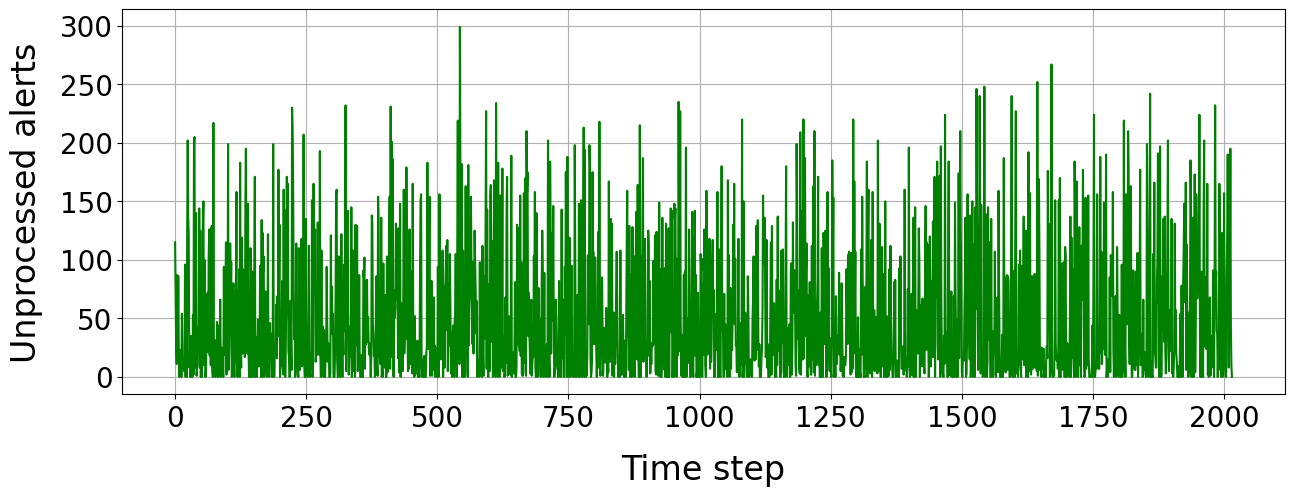

In [35]:
plt.figure(figsize=(15, 5))
plt.plot(all_Analyst_workload, c='g')
plt.xlabel("Time step", fontsize=24, labelpad=15)
plt.ylabel("Unprocessed alerts", fontsize=24, labelpad=12)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.show()

In [36]:
# Function to count dictionaries with 'alert_action': 1 in each inner list
def count_alert_action_1(list_of_lists):
    counts = []
    for inner_list in list_of_lists:
        count = sum(1 for dic in inner_list if dic.get('alert_action') == 1)
        counts.append(count)
    return counts

# Call the function
deferred_alerts_to_analyst = count_alert_action_1(all_alert_after_action_01)

In [ ]:
with open('deferred_alerts_to_analyst_L2D_CICIDS2017.json', 'w') as f:
    json.dump(deferred_alerts_to_analyst, f)

In [37]:
counts_all_alert_list_without_Normal = [len(inner_list) for inner_list in all_alert_list_without_Normal]

In [38]:
len(deferred_alerts_to_analyst)

2016

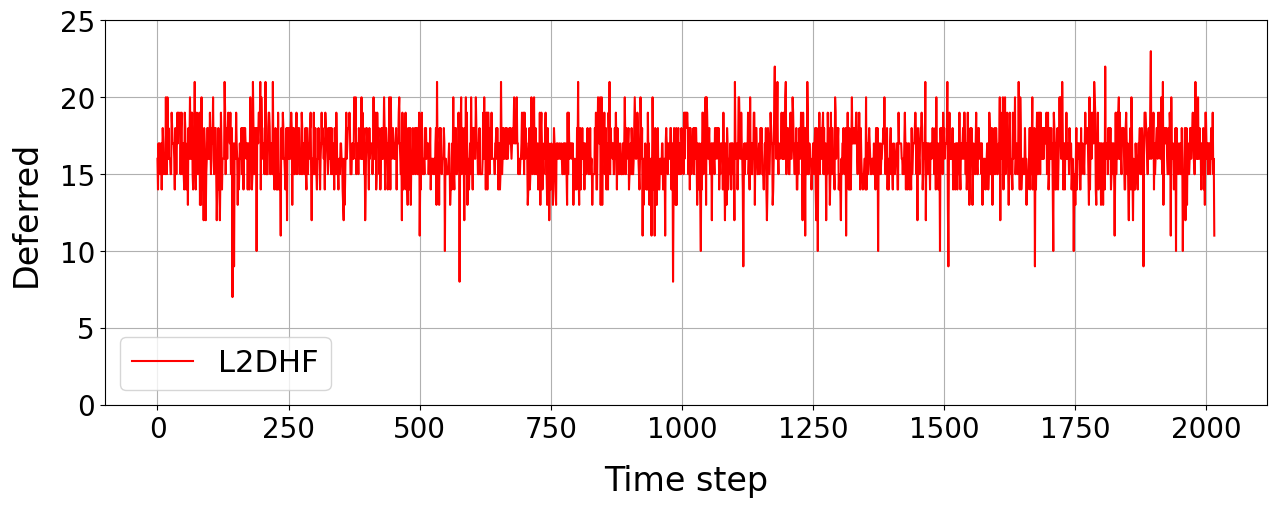

In [39]:
plt.figure(figsize=(15, 5))
plt.plot(deferred_alerts_to_analyst, c='r')
plt.xlabel("Time step", fontsize=24, labelpad=15)
plt.ylabel("Deferred", fontsize=24, labelpad=12)
plt.ylim(-0.05, 25)
plt.legend(fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.show()

In [ ]:
with open('all_Remaining_time_L2D_CICIDS2017.json', 'w') as f:
    json.dump(all_Remaining_time, f)

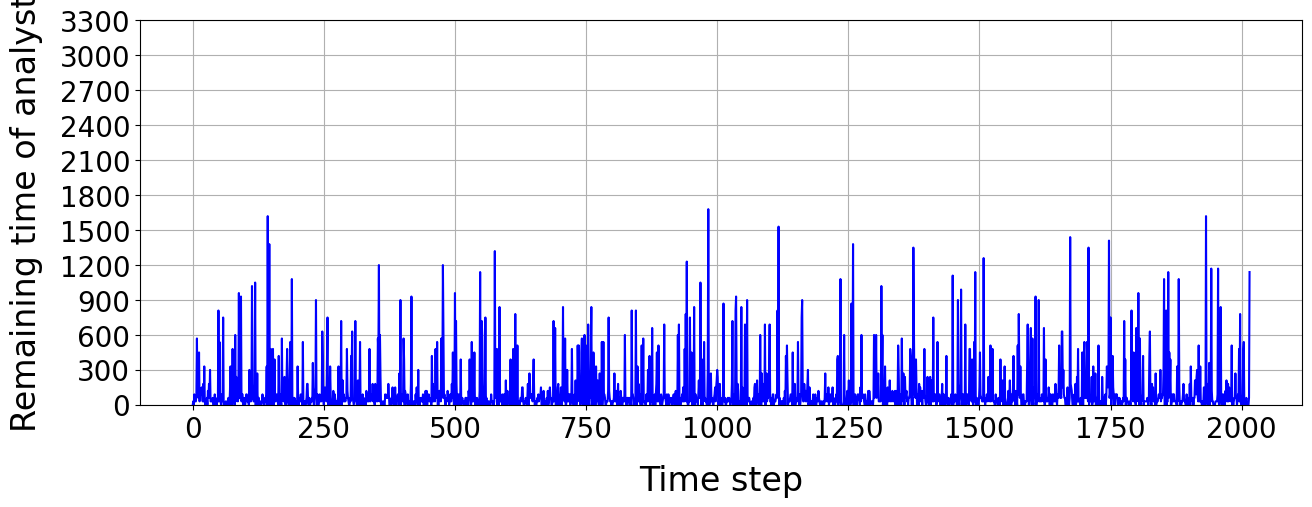

In [40]:
plt.figure(figsize=(15, 5))
plt.plot(all_Remaining_time, c='blue')

plt.xlabel("Time step", fontsize=24, labelpad=15)
plt.ylabel("Remaining time of analyst", fontsize=24, labelpad=12)
plt.ylim(-5, 100)
plt.yticks(range(0, 3500, 300), fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.show()

In [ ]:
with open('all_time_step_execution_time_L2D_CICIDS2017.json', 'w') as f:
    json.dump(all_time_step_execution_time, f)

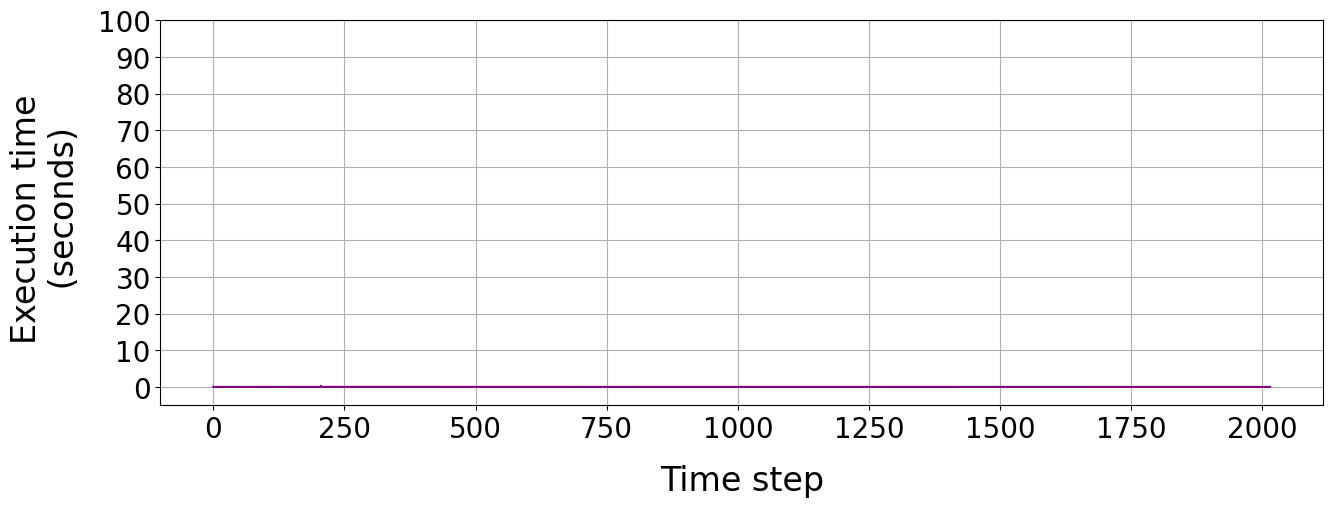

In [41]:
plt.figure(figsize=(15, 5))
plt.plot(all_time_step_execution_time, c='purple')

plt.xlabel("Time step", fontsize=24, labelpad=15)
plt.ylabel("Execution time \n (seconds)", fontsize=24, labelpad=12)
plt.ylim(-5, 100)
plt.yticks(range(0, 101, 10), fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.show()

In [ ]:
# First 500 and last 516

In [42]:
# unprocessed
first_half_all_Analyst_workload  = all_Analyst_workload [:499]  
last_half_all_Analyst_workload  = all_Analyst_workload [1500:]  

# Calculate the averages
avg_first_half_all_Analyst_workload  = sum(first_half_all_Analyst_workload) / len(first_half_all_Analyst_workload)
avg_last_half_all_Analyst_workload  = sum(last_half_all_Analyst_workload) / len(last_half_all_Analyst_workload)

print("Average of first 500 items all_Analyst_workload :", avg_first_half_all_Analyst_workload)
print("Average of last 516 items all_Analyst_workload :", avg_last_half_all_Analyst_workload)

Average of first 500 items all_Analyst_workload : 49.19639278557114
Average of last 500 items all_Analyst_workload : 54.12596899224806


In [43]:
# deferrals 
first_half_deferred_alerts_to_analyst  = deferred_alerts_to_analyst [:499]  
last_half_deferred_alerts_to_analyst  = deferred_alerts_to_analyst [1500:]  

# Calculate the averages
avg_first_half_deferred_alerts_to_analyst  = sum(first_half_deferred_alerts_to_analyst) / len(first_half_deferred_alerts_to_analyst)
avg_last_half_deferred_alerts_to_analyst  = sum(last_half_deferred_alerts_to_analyst) / len(last_half_deferred_alerts_to_analyst)

print("Average of first 500 items deferred_alerts_to_analyst :", avg_first_half_deferred_alerts_to_analyst)
print("Average of last 516 items deferred_alerts_to_analyst :", avg_last_half_deferred_alerts_to_analyst)

Average of first 500 items deferred_alerts_to_analyst : 16.450901803607213
Average of last 500 items deferred_alerts_to_analyst : 16.385658914728683


In [46]:
# deferrals 
middle1_deferred_alerts_to_analyst  = deferred_alerts_to_analyst [500:999]  
middle2_deferred_alerts_to_analyst  = deferred_alerts_to_analyst [1000:1499]  

# Calculate the averages
avg_middle1_deferred_alerts_to_analyst  = sum(middle1_deferred_alerts_to_analyst) / len(middle1_deferred_alerts_to_analyst)
avg_middle2_deferred_alerts_to_analyst  = sum(middle2_deferred_alerts_to_analyst) / len(middle2_deferred_alerts_to_analyst)

print("avg_middle1_deferred_alerts_to_analyst :", avg_middle1_deferred_alerts_to_analyst)
print("avg_middle2_deferred_alerts_to_analyst :", avg_middle2_deferred_alerts_to_analyst)

avg_middle1_deferred_alerts_to_analyst : 16.23446893787575
avg_middle2_deferred_alerts_to_analyst : 16.35671342685371


In [ ]:
# Overall average, unprocessed and deferred alerts

In [44]:
# Unprocessed alerts
avg_all_Analyst_workload  = sum(all_Analyst_workload) / len(all_Analyst_workload)

print("Average all_Analyst_workload :", avg_all_Analyst_workload)


Average all_Analyst_workload : 52.101190476190474


In [45]:
# Deferred alerts

avg_deferred_alerts_to_analyst  = sum(deferred_alerts_to_analyst) / len(deferred_alerts_to_analyst)

print("Average deferred_alerts_to_analyst :", avg_deferred_alerts_to_analyst)


Average deferred_alerts_to_analyst : 16.359623015873016
